## 预测房价
数据集Bart de Cock于2011年收集 (De Cock, 2011)， 涵盖了2006-2010年期间亚利桑那州埃姆斯市的房价。首先，我们建立字典DATA_HUB， 它可以将数据集名称的字符串映射到数据集相关的二元组上， 这个二元组包含数据集的url和验证文件完整性的sha-1密钥。 所有类似的数据集都托管在地址为DATA_URL的站点上。

In [60]:
import hashlib
import os
import tarfile
import zipfile
import requests

DATA_HUB = dict()
DATA_URL = 'http://d2l-data.s3-accelerate.amazonaws.com/'

 下面的download函数用来下载数据集， 将数据集缓存在本地目录（默认情况下为../data）中， 并返回下载文件的名称。 如果缓存目录中已经存在此数据集文件，并且其sha-1与存储在DATA_HUB中的相匹配， 我们将使用缓存的文件，以避免重复的下载。

In [61]:
def download(name,cache_dir=os.path.join('..','data')):
    """下载一个DATA_HUB中的文件，返回本地文件名"""
    assert name in DATA_HUB,f"{name} 不存在于 {DATA_HUB}"
    url,sha1_hash = DATA_HUB[name]
    os.makedirs(cache_dir,exist_ok=True)
    fname = os.path.join(cache_dir,url.split('/')[-1])
    if os.path.exists(fname):
        sha1 = hashlib.sha1()
        with open(fname,'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
                sha1.update(data)
        if sha1.hexdigest() == sha1_hash:
            return fname # 命中缓存
        print(f'正在从{url}下载{fname}...')
        r = requests.get(url,stream=True,verify=True)
        with open(fname,'wb') as f:
            f.write(r.content)
        return fname

还要实现两个实用函数，一个将下载并解压缩一个zip或tar文件，另一个是将数据集从DATA_HUB下载到缓存目录

In [62]:
def download_extract(name,folder=None):
    """下载并解压zip/tar文件"""
    fname = download(name)
    base_dir = os.path.dirname(fname)
    data_dir,ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname,'r')
    elif ext in ('.tar','.gz'):
        fp = tarfile.open(fname,'r')
    else:
        assert False,'只有zip/tar文件可以被解压缩'
    fp.extractall() # 展开归档文件中的所有内容，创建与归档内结构一致的目录结构，并把文件解压到相应的位置
    return os.path.join(base_dir,folder) if folder else data_dir

def download_all():
    """下载DATA_HUB中的所有文件"""
    for name in DATA_HUB:
        download(name)

### 访问和读取数据集
竞赛数据分为训练集和测试集。 每条记录都包括房屋的属性值和属性，如街道类型、施工年份、屋顶类型、地下室状况等。 这些特征由各种数据类型组成。 例如，建筑年份由整数表示，屋顶类型由离散类别表示，其他特征由浮点数表示。 这就是现实让事情变得复杂的地方：例如，一些数据完全丢失了，缺失值被简单地标记为“NA”。 每套房子的价格只出现在训练集中（毕竟这是一场比赛）。 我们将希望划分训练集以创建验证集，但是在将预测结果上传到Kaggle之后， 我们只能在官方测试集中评估我们的模型。

In [63]:
import pandas as pd 
import numpy as np
import torch
from torch import nn
from d2l import torch as d2l
# 使用上面定义的脚本下载并缓存Kaggle房屋数据集
DATA_HUB['kaggle_house_train'] = (DATA_URL + 'kaggle_house_pred_train.csv',
    '585e9cc93e70b39160e7921475f9bcd7d31219ce' )
DATA_HUB['kaggle_house_test'] = (DATA_URL + 'kaggle_house_pred_test.csv',
    'fa19780a7b011d9b009e8bff8e99922a8ee2eb90')

# 使用pandas分别加载包含训练数据和测试数据的两个CSV文件
train_data = pd.read_csv(download('kaggle_house_train'))
test_data = pd.read_csv(download('kaggle_house_test'))

# 训练数据集包括1460个样本，每个样本80个特征和1个标签， 而测试数据集包含1459个样本，每个样本80个特征。
print(train_data.shape)
print(test_data.shape)

# 查看前四个和最后两个特征，以及相应标签(房价)
print(train_data.iloc[0:4,[0,1,2,3,-3,-2,-1]]) # 0:4 表示行数，0，1，2... 表示显示的列



(1460, 81)
(1459, 80)
   Id  MSSubClass MSZoning  LotFrontage SaleType SaleCondition  SalePrice
0   1          60       RL         65.0       WD        Normal     208500
1   2          20       RL         80.0       WD        Normal     181500
2   3          60       RL         68.0       WD        Normal     223500
3   4          70       RL         60.0       WD       Abnorml     140000


In [64]:
# 在每个样本中，第一个特征是ID， 这有助于模型识别每个训练样本。 虽然这很方便，但它不携带任何用于预测的信息。 因此，在将数据提供给模型之前，我们将其从数据集中删除。
all_features = pd.concat((train_data.iloc[:,1:],test_data.iloc[:,1:]))

### 数据预处理
在开始建模之前，我们需要对数据进行预处理。 首先，我们将所有缺失的值替换为相应特征的平均值。然后，为了将所有特征放在一个共同的尺度上， 我们通过将特征重新缩放到零均值和单位方差来标准化数据。直观地说，我们标准化数据有两个原因： 首先，它方便优化。 其次，因为我们不知道哪些特征是相关的， 所以我们不想让惩罚分配给一个特征的系数比分配给其他任何特征的系数更大。

In [65]:
# 若无法获得测试数据，则可根据训练数据计算均值和标准差
numeric_features = all_features.dtypes[all_features.dtypes != 'object'].index # 获取all_features中所有非对象类型列名的索引对象，是一个不可变的数组
all_features[numeric_features] = all_features[numeric_features].apply(lambda x: (x -x.mean()) / (x.std())) #对数值型特征进行标准化处理

# 在标准化数据之后，所有均值消失，因此我们可以将缺失值设置为0
all_features[numeric_features] = all_features[numeric_features].fillna(0) # fillna 使用指定的方法来填充NA/NAN值

接下来，我们处理离散值。 这包括诸如“MSZoning”之类的特征。 我们用**独热编码**替换它们， 方法与前面将多类别标签转换为向量的方式相同，例如，“MSZoning”包含值“RL”和“Rm”。 我们将创建两个新的指示器特征“MSZoning_RL”和“MSZoning_RM”，其值为0或1。 根据独热编码，如果“MSZoning”的原始值为“RL”， 则：“MSZoning_RL”为1，“MSZoning_RM”为0。 pandas软件包会自动为我们实现这一点。
- 独热编码
  独热编码（One-hot Encoding）是一种将分类变量转换为数值型数据的常见方法，它常用于机器学习和数据分析中处理类别特征。在独热编码中，每一个分类标签会被转换成一个二进制向量，该向量长度等于所有可能类别的数量，且只有一个位置上的值为1，其余位置均为0。这个“1”所在的位置对应于原始数据中的类别。假设有一个分类特征有三个类别：红色、蓝色、绿色。经过独热编码后，红色会表示为 [1, 0, 0]，蓝色为 [0, 1, 0]，绿色为 [0, 0, 1]。这样做的目的是使得算法能够更好地理解和处理分类特征，特别是对于那些期望输入是数值形式的模型（如线性回归、逻辑回归、神经网络等）来说，它们无法直接处理类别标签。

In [66]:
# "Dummy_na=True" 将"na"视为有效的特征值，并为其创建指示符特征
all_features = pd.get_dummies(all_features,dummy_na=True) # get_dummies()将分类变量转变为哑变量，【哑变量（Dummy Variable）是一种特殊类型的变量，用于将分类或名义变量编码为数值形式，以便于在回归分析、逻辑回归、判别分析等模型中处理。哑变量通常取值为0或1】
all_features = all_features * 1 # 热编码的时候将0和1编码成了true和false，乘以1以后变成数值类型，防止下面的操作报错
all_features.shape

(2919, 331)

可以看到此转换会将特征的总数量从79个增加到331个.最后通过values属性，我们可以从pandas格式中提取Numpy格式，并将其转换为张量表示用于训练。

In [67]:
n_train = train_data.shape[0]
train_features = torch.tensor(all_features[:n_train].values, dtype=torch.float32)
test_features = torch.tensor(all_features[n_train:].values, dtype=torch.float32)
train_labels = torch.tensor(
    train_data.SalePrice.values.reshape(-1, 1), dtype=torch.float32)

### 训练
首先，我们训练一个带有损失平方的线性模型。 显然线性模型很难让我们在竞赛中获胜，但线性模型提供了一种健全性检查， 以查看数据中是否存在有意义的信息。 如果我们在这里不能做得比随机猜测更好，那么我们很可能存在数据处理错误。 如果一切顺利，线性模型将作为基线（baseline）模型， 让我们直观地知道最好的模型有超出简单的模型多少。

In [68]:
loss = nn.MSELoss()
in_features = train_features.shape[1]

def get_net():
    net = nn.Sequential(nn.Linear(in_features,1)) # in_features表示输入维度，1表示输出维度
    return net


房价就像股票价格一样，我们关心的是相对数量，而不是绝对数量。 因此，我们更关心相对误差$\frac{y-\hat{y}}{y}$,而不是绝对误差$y-\hat{y}$解决这个问题的一种方法是用价格预测的对数来衡量差异。$$\sqrt{\frac1n\sum_{i=1}^n\left(\log y_i-\log\hat{y_i}\right)^2}.$$

In [69]:
def log_rmse(net,features,labels):
    # 为了在取对数时进一步稳定该值，将小于1的值设置为1
    clipped_preds = torch.clamp(net(features),1,float('inf')) # 使用clamp函数限制神经网络输出最小值为1，
    rmse = torch.sqrt(loss(torch.log(clipped_preds),torch.log(labels))) # 对数均方根误差
    return rmse.item()

In [70]:
# 训练函数借助Adam优化器
def train(net,train_features,train_labels,test_features,test_labels,num_epochs,learning_rate,weight_decay,batch_size):
    train_ls,test_ls = [],[] # 记录训练过程中的损失值的列表
    train_iter = d2l.load_array((train_features,train_labels),batch_size)
    # 使用Adam优化算法
    optimizer = torch.optim.Adam(net.parameters(),
                                 lr = learning_rate,
                                 weight_decay = weight_decay)
    for epoch in range(num_epochs):
        for X,y in train_iter:
            optimizer.zero_grad()
            l = loss(net(X),y)
            l.backward()
            optimizer.step()
        train_ls.append(log_rmse(net,train_features,train_labels))
        if test_labels is not None:
            test_ls.append(log_rmse(net,test_features,test_labels))
    return train_ls,test_ls

### K折交叉验证
原始训练数据被分成K个不重叠的子集。 然后执行K次模型训练和验证，每次在K-1个子集上进行训练， 并在剩余的一个子集（在该轮中没有用于训练的子集）上进行验证。 最后，通过对K次实验的结果取平均来估计训练和验证误差。
我们首先需要定义一个函数，在K折交叉验证过程中返回第i折的数据.具体地说，它选择第i个切片作为验证数据，其余部分作为训练数据。 注意，这并不是处理数据的最有效方法，如果我们的数据集大得多，会有其他解决办法。

In [74]:
def get_k_fold_data(k,i,X,y):
    assert k > 1
    fold_size =X.shape[0] // k
    X_train,y_train = None,None
    for j in range(k):
        idx = slice(j * fold_size,(j + 1) * fold_size)
        X_part,y_part = X[idx,:],y[idx]
        if j == i:
            X_valid,y_valid = X_part,y_part
        elif X_train is None:
            X_train,y_train = X_part,y_part
        else:
            X_train = torch.cat([X_train,X_part],0)
            y_train = torch.cat([y_train,y_part],0)
    return X_train,y_train,X_valid,y_valid  

# 当我们在K折交叉验证中训练K次后，返回训练和验证误差的平均值

def k_fold(k,X_train,y_train,num_epochs,learning_rate,weight_decay,batch_size):
    train_l_sum,valid_l_sum = 0,0 # 初始化训练损失和验证损失的累加器变量
    for i in range(k):
        data = get_k_fold_data(k,i,X_train,y_train) # 获取当前轮次的训练集和验证集
        net = get_net()
        train_ls,valid_ls = train(net,*data,num_epochs,learning_rate,weight_decay,batch_size) # *data是一种解包操作，表妹这个位置的参数应该是一个可迭代对象
        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]
        if i == 0: # 若这是第一轮（i=0），则绘制训练损失与验证损失随训练轮数变化的曲线。
            d2l.plot(list(range(1,num_epochs+1)),[train_ls,valid_ls],xlabel='epoch',ylabel='rmse',xlim=[1,num_epochs],
                     legend=['train','valid'],yscale='log')
        print(f'折{i+1},训练log rmse{float(train_ls[-1]):f},'f'验证log rmse{float(valid_ls[-1]):f}')
    return train_l_sum/k,valid_l_sum/k     

### 模型选择
找到一组调优的超参数可能需要时间，这取决于一个人优化了多少变量。 有了足够大的数据集和合理设置的超参数，K折交叉验证往往对多次测试具有相当的稳定性。 然而，如果我们尝试了不合理的超参数，我们可能会发现验证效果不再代表真正的误差。

折1,训练log rmse0.130806,验证log rmse0.128540
折2,训练log rmse0.127171,验证log rmse0.143407
折3,训练log rmse0.124984,验证log rmse0.130080
折4,训练log rmse0.130510,验证log rmse0.127849
折5,训练log rmse0.125436,验证log rmse0.155565
5-折验证: 平均训练log rmse: 0.127781, 平均验证log rmse: 0.137088


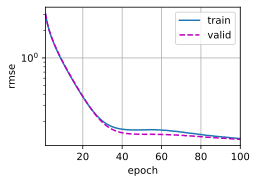

In [141]:
k, num_epochs, lr, weight_decay, batch_size = 5, 100, 5.2, 0, 32
train_l, valid_l = k_fold(k, train_features, train_labels, num_epochs, lr,
                          weight_decay, batch_size)
print(f'{k}-折验证: 平均训练log rmse: {float(train_l):f}, '
      f'平均验证log rmse: {float(valid_l):f}')

### 提交Kaggle预测
既然我们知道应该选择什么样的超参数， 我们不妨使用所有数据对其进行训练 （而不是仅使用交叉验证中使用的1-1/K的数据）然后，我们通过这种方式获得的模型可以应用于测试集。 将预测保存在CSV文件中可以简化将结果上传到Kaggle的过程。

训练log rmse:0.118477


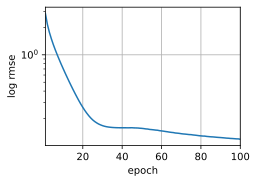

: 

In [142]:
def train_and_pred(train_features,test_features,train_labels,test_data,num_epochs,lr,weight_decay,batch_size):
    net = get_net()
    train_ls,_ = train(net,train_features,train_labels,None,None,num_epochs,lr,weight_decay,batch_size)
    d2l.plot(np.arange(1,num_epochs+1),[train_ls],xlabel='epoch',ylabel='log rmse',xlim=[1,num_epochs],yscale='log')
    print(f'训练log rmse:{float(train_ls[-1]):f}')
    # 将网络应用于测试集
    preds = net(test_features).detach().numpy()
    # 将其重新格式化以导出到kaggle
    test_data['SalePrice'] = pd.Series(preds.reshape(1,-1)[0])
    submission = pd.concat([test_data['Id'],test_data['SalePrice']],axis=1)
    submission.to_csv('submission.csv',index=False)

train_and_pred(train_features,test_features,train_labels,test_data,num_epochs,lr,weight_decay,batch_size)